Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_6 (InputLayer)  │ (None, 28, 28, 1)     │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_12 (Conv2D)          │ (None, 26, 26, 8)     │         80 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_13 (Conv2D)          │ (None, 24, 24, 8)     │        584 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten_6 (Flatten)         │ (None, 4608)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_24 (Dense)            │ (None, 512)           │  2,359,808 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_25 (Dense)            │ (None, 256)           │    131,328 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_26 (Dense)            │ (None, 128)           │     32,896 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_27 (Dense)            │ (None, 10)            │      1,290 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,525,986 (9.64 MB)

 Trainable params: 2,525,986 (9.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 58ms/step - accuracy: 0.8564 - loss: 1.3194 - val_accuracy: 0.9666 - val_loss: 0.1095
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.9783 - loss: 0.0723 - val_accuracy: 0.9737 - val_loss: 0.0861
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9881 - loss: 0.0373 - val_accuracy: 0.9743 - val_loss: 0.0883
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 78s 67ms/step - accuracy: 0.9896 - loss: 0.0301 - val_accuracy: 0.9751 - val_loss: 0.0881
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.9931 - loss: 0.0229 - val_accuracy: 0.9734 - val_loss: 0.1030
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 49ms/step - accuracy: 0.9921 - loss: 0.0255 - val_accuracy: 0.9811 - val_loss: 0.0773
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 45s 48ms/step - accuracy: 0.9946 - loss: 0.0181 - val_accuracy: 0.9783 - val_loss: 0.0997
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9935 - loss: 0.0204 - 

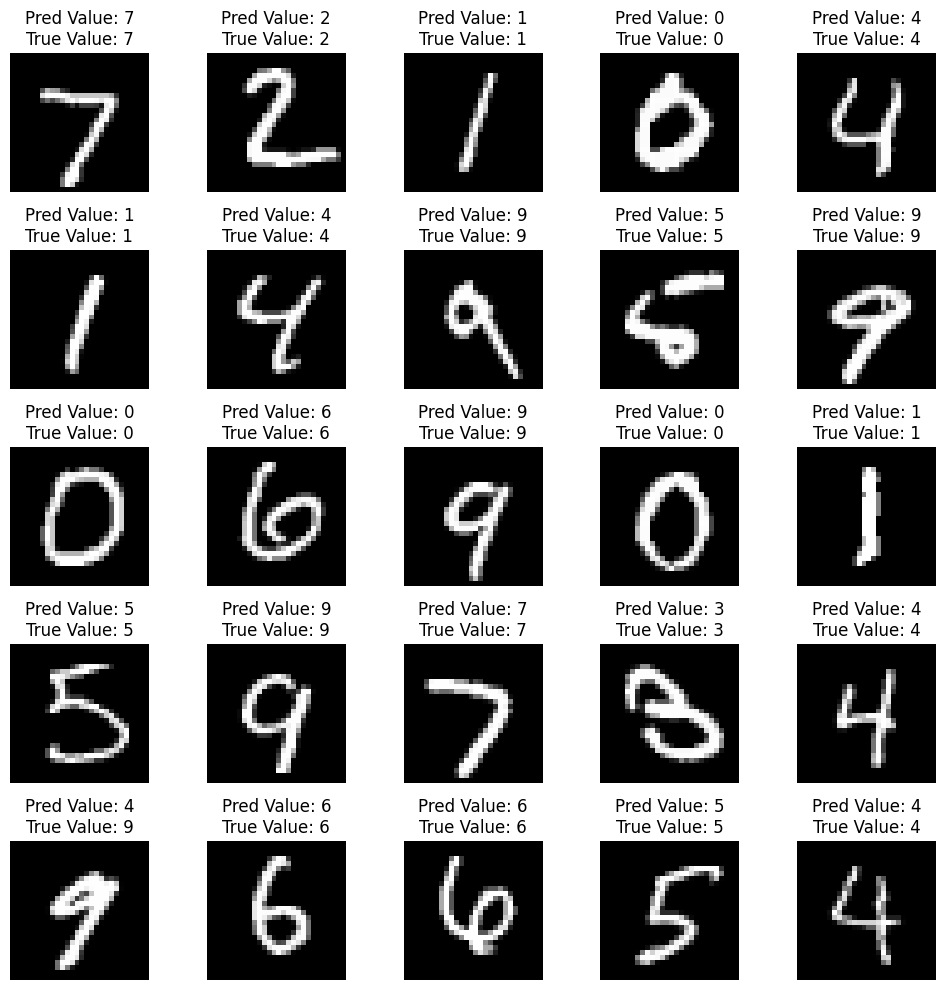

In [7]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense,Flatten,Conv2D
import matplotlib.pyplot as plt

num_classes=10
(trainX,trainY),(testX,testY)=load_data()

inputs = Input(shape=(28, 28, 1))
x=Conv2D(filters=8,kernel_size=(3,3),activation='relu')(inputs)
x1=Conv2D(filters=8,kernel_size=(3,3),activation='relu')(x)
x2=Flatten()(x1)
x3=Dense(512,activation='relu')(x2)
x4=Dense(256,activation='relu')(x3)
x5=Dense(128,activation='relu')(x4)
outputs=Dense(num_classes,activation='softmax')(x5)
model=Model(inputs,outputs)
model.summary(show_trainable='true',)
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history=model.fit(trainX,trainY,epochs=10,batch_size=64,validation_data=(testX,testY),verbose=1)

loss,accuracy=model.evaluate(testX,testY,verbose=0)
print(f"loss={loss}")
print(f"accuracy={accuracy}")

# Get predictions
predY = model.predict(testX)
print(testX.shape)
print(predY.shape)
pred_labels = predY.argmax(axis=1)

# Plot 25 test images with predictions
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(testX[i], cmap='gray')
    plt.title(f"Pred Value: {pred_labels[i]}\nTrue Value: {testY[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()